# 6. Subgroup Equity

**Project:** Predicting colorectal cancer screening non-compliance to guide targeted outreach
**Part of:** the evaluation stage, alongside `5 Evaluation.ipynb`. Split into its own notebook
because it covers a distinct question from either of `5`'s sections -- not "which model performs
best overall" (model comparison) or "is this one model's probabilities trustworthy" (calibration),
but "does whichever model is carried forward perform consistently across the subgroups the
proposal names." That's the proposal's third stated study objective, not just an evaluation
nicety, and it needs its own per-group breakdowns and charts rather than a couple of extra columns
on an existing table -- which is why it's a separate notebook rather than a section bolted onto
`5` (specificity, by contrast, was just an extra column on `5`'s existing comparison table and
now lives there instead).

**This notebook does not fit anything new.** It loads every model already registered by
`4a`-`4d`/`5` from the shared manifest (including `gb_M3_tuned_calibrated`) and evaluates the
leading calibrated model against the held-out test split, broken out by subgroup -- no refitting.

**Covers proposal study objective 3:** subgroup/equity performance across insurance, income and
ethnicity -- "explores whether predictive performance is equitable across insurance, income and
ethnic subgroups" -- not computed anywhere else in the current notebooks.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

sys.path.insert(0, str(Path.cwd()))
from pipeline_components import M3_FEATURES, compute_classification_metrics, make_model_registry

DATA_DIR = Path("../data")
PROCESSED_DIR = DATA_DIR / "processed"
MODEL_DIR = PROCESSED_DIR / "modelling"
MODELS_DIR = MODEL_DIR / "models"
MANIFEST_PATH = MODEL_DIR / "model_registry_manifest.csv"
FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

ANALYTIC_PATH = PROCESSED_DIR / "crc_analytic_dataset.csv"
SPLIT_PATH = MODEL_DIR / "train_calibration_test_split.csv"
for p in [ANALYTIC_PATH, SPLIT_PATH, MANIFEST_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"{p} not found. Run '3 Data Processing.ipynb', '4a'-'4d', and '5 Evaluation.ipynb' first.")

df = pd.read_csv(
    ANALYTIC_PATH,
    dtype={"respondent_id": "string", "state_fips": "string"},
    low_memory=False,
)
split_assignment = pd.read_csv(SPLIT_PATH, dtype={"respondent_id": "string"})
df = df.merge(split_assignment, on="respondent_id", validate="one_to_one")

X_test = df.loc[df["split"] == "test", M3_FEATURES]
y_test = df.loc[df["split"] == "test", "crc_noncompliant"]
print(f"Test set: n={len(X_test):,}   non-compliance rate={y_test.mean():.4f}")

_, _, load_registry = make_model_registry(MODELS_DIR, MANIFEST_PATH)
MODEL_REGISTRY = load_registry()
print(f"Loaded {len(MODEL_REGISTRY)} models from the shared manifest: {sorted(MODEL_REGISTRY.keys())}")

Test set: n=45,530   non-compliance rate=0.2648


Loaded 17 models from the shared manifest: ['ffnn_M1', 'ffnn_M2', 'ffnn_M3', 'ffnn_M3_tuned', 'gb_M1', 'gb_M2', 'gb_M3', 'gb_M3_knn_imputed', 'gb_M3_tuned', 'gb_M3_tuned_calibrated', 'logreg_M1', 'logreg_M2', 'logreg_M3', 'rf_M1', 'rf_M2', 'rf_M3', 'rf_M3_tuned']


## Subgroup equity performance

Per proposal study objective 3, performance is broken out by `insurance_status`, `income_group`
and `race_ethnicity` -- the three fields the proposal names. Evaluated on
`gb_M3_tuned_calibrated` (the calibrated leading model), on the held-out test split, so the
"mean predicted risk" column is directly comparable to the observed rate -- if calibration holds
equally well across subgroups (not just on average, which was already checked in
`5 Evaluation.ipynb`), those two columns should track each other within every subgroup, too.

In [2]:
EQUITY_FIELDS = ["insurance_status", "income_group", "race_ethnicity"]
LEADING_CALIBRATED_MODEL = "gb_M3_tuned_calibrated"
leading_pipeline = MODEL_REGISTRY[LEADING_CALIBRATED_MODEL]["pipeline"]
proba_test = leading_pipeline.predict_proba(X_test[M3_FEATURES])[:, 1]

def subgroup_table(field):
    rows = []
    for level, idx in X_test.groupby(field, observed=True).groups.items():
        y_g = y_test.loc[idx]
        p_g = proba_test[X_test.index.get_indexer(idx)]
        y_pred_g = (p_g >= 0.5).astype(int)
        n_pos, n_neg = int(y_g.sum()), int((1 - y_g).sum())
        row = {
            "Equity field": field, "Level": level, "N": len(idx),
            "Observed rate": y_g.mean(), "Mean predicted risk": p_g.mean(),
        }
        # AUROC/AUPRC need both classes present in the subgroup -- guard rather than let sklearn raise.
        if n_pos > 0 and n_neg > 0:
            from sklearn.metrics import roc_auc_score, average_precision_score, recall_score
            row["AUROC"] = roc_auc_score(y_g, p_g)
            row["AUPRC"] = average_precision_score(y_g, p_g)
            row["Sensitivity"] = recall_score(y_g, y_pred_g)
            row["Specificity"] = recall_score(y_g, y_pred_g, pos_label=0)
        else:
            row["AUROC"] = row["AUPRC"] = row["Sensitivity"] = row["Specificity"] = np.nan
        rows.append(row)
    return pd.DataFrame(rows)

subgroup_equity_table = pd.concat([subgroup_table(f) for f in EQUITY_FIELDS], ignore_index=True)
subgroup_equity_table = subgroup_equity_table.sort_values(["Equity field", "N"], ascending=[True, False])
subgroup_equity_table.to_csv(MODEL_DIR / "subgroup_equity_performance.csv", index=False)
subgroup_equity_table.round(4)

,Equity field,Level,N,Observed rate,Mean predicted risk,AUROC,AUPRC,Sensitivity,Specificity
8,income_group,"$50,000 to < $100,000",11617,0.2314,0.2335,0.7687,0.5551,0.3281,0.9479
3,income_group,"$100,000 to < $200,000",9037,0.2254,0.2294,0.7605,0.5398,0.2847,0.9599
10,income_group,Not reported,6936,0.2803,0.2754,0.7575,0.6029,0.3529,0.9463
7,income_group,"$35,000 to < $50,000",4691,0.2910,0.2862,0.7685,0.6356,0.4081,0.9429
6,income_group,"$25,000 to < $35,000",3957,0.3210,0.3097,0.7435,0.6306,0.4071,0.9248
4,income_group,"$15,000 to < $25,000",3546,0.3302,0.3317,0.7311,0.6162,0.3749,0.9187
5,income_group,"$200,000 or more",3484,0.1998,0.2036,0.7583,0.4643,0.2112,0.9663
9,income_group,"Less than $15,000",2262,0.3908,0.3904,0.7285,0.6616,0.4118,0.8853
0,insurance_status,Insured,42533,0.2444,0.2438,0.7488,0.5344,0.2793,0.9553
2,insurance_status,Uninsured,1701,0.7008,0.7073,0.7464,0.8667,0.8800,0.3458


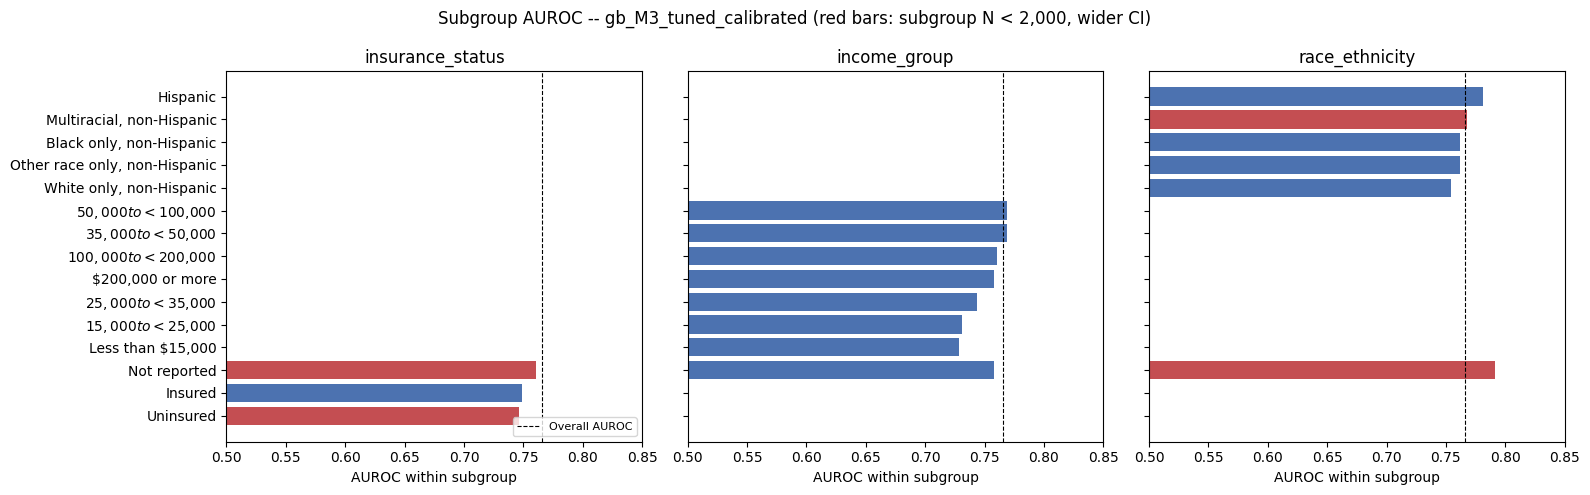

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, field in zip(axes, EQUITY_FIELDS):
    sub = subgroup_equity_table[subgroup_equity_table["Equity field"] == field].sort_values("AUROC")
    colors = ["#C44E52" if n < 2000 else "#4C72B0" for n in sub["N"]]
    ax.barh(sub["Level"], sub["AUROC"], color=colors)
    ax.axvline(MODEL_REGISTRY[LEADING_CALIBRATED_MODEL]["metrics"]["AUROC"],
               linestyle="--", color="black", linewidth=0.8, label="Overall AUROC")
    ax.set_xlim(0.5, 0.85)
    ax.set_title(field)
    ax.set_xlabel("AUROC within subgroup")
axes[0].legend(fontsize=8, loc="lower right")
fig.suptitle(f"Subgroup AUROC -- {LEADING_CALIBRATED_MODEL} (red bars: subgroup N < 2,000, wider CI)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig22_subgroup_equity_auroc.png", dpi=150)
plt.show()

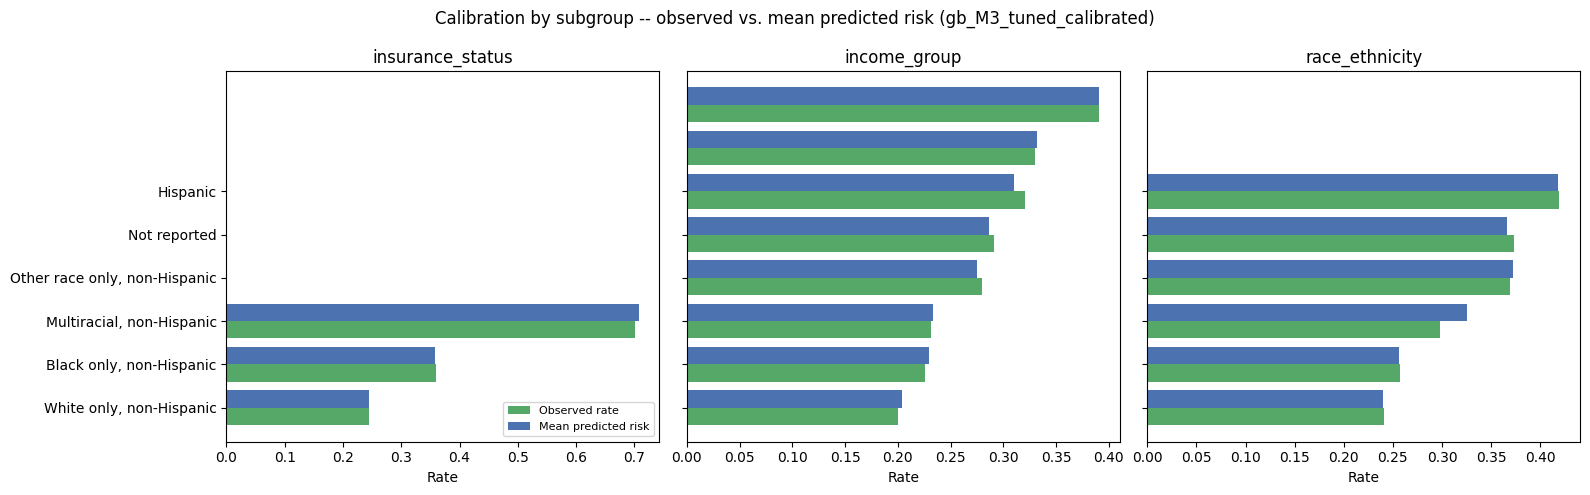

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, field in zip(axes, EQUITY_FIELDS):
    sub = subgroup_equity_table[subgroup_equity_table["Equity field"] == field].sort_values("Observed rate")
    y_pos = np.arange(len(sub))
    ax.barh(y_pos - 0.2, sub["Observed rate"], height=0.4, color="#55A868", label="Observed rate")
    ax.barh(y_pos + 0.2, sub["Mean predicted risk"], height=0.4, color="#4C72B0", label="Mean predicted risk")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(sub["Level"])
    ax.set_title(field)
    ax.set_xlabel("Rate")
axes[0].legend(fontsize=8, loc="lower right")
fig.suptitle(f"Calibration by subgroup -- observed vs. mean predicted risk ({LEADING_CALIBRATED_MODEL})")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig23_subgroup_equity_calibration.png", dpi=150)
plt.show()

**Reading the equity table:** the encouraging finding first -- calibration holds up across
every subgroup checked, not just on average. `Mean predicted risk` tracks `Observed rate` closely
within every level of every field (e.g. uninsured: 70.7% predicted vs. 70.1% observed; Hispanic:
predicted and observed both land in the low-40s; the largest gap anywhere is income's
"Not reported" level at roughly 2.5 points). The isotonic correction was fit once on the overall
calibration set, not separately per subgroup, so this isn't guaranteed -- it's a real, checkable
result, not a byproduct of how the calibration was built.

**AUROC stays in a fairly tight band across all three fields** (roughly 0.73-0.79), with no group
left meaningfully behind the overall 0.766. The widest single-field spread is income
(0.729 for "Less than $15,000" to 0.769 for "$50,000-$100,000"), a real but modest ~0.04 gap, not
a case of the model failing outright for the lowest-income respondents. Race/ethnicity shows the
opposite of an obvious equity problem -- the largest group (White, non-Hispanic, n=34,911) has the
*lowest* subgroup AUROC (0.754), while Hispanic (0.782) and the small "Not reported" group (0.791)
rank slightly higher. Insured vs. uninsured -- arguably the highest-stakes comparison given how
different their non-compliance rates are (24.4% vs. 70.1%) -- are close on AUROC (0.749 vs. 0.746),
meaning the model isn't quietly worse at ranking the group it matters most for reaching.

**Caveats worth carrying into the report:** four subgroups have fewer than 2,000 test respondents
(uninsured, insurance "Not reported", multiracial, race "Not reported" -- flagged red in the AUROC
chart) and their AUROC estimates should be read as noisier than the larger groups', not as
precise. Sensitivity and specificity swing hard with each subgroup's own base rate rather than
reflecting differential model quality -- uninsured respondents get 88% sensitivity almost
mechanically, because 70% of them are actually non-compliant and the model's calibrated 0.5
threshold now rarely predicts "compliant" for anyone in a group this skewed; that's arithmetic on
the base rate, not evidence the model treats this group better. AUROC and the
predicted-vs-observed comparison are the two numbers that isolate genuine model quality from base
rate, which is why they're the ones read above.